# Imports and configs

In [28]:
from sklearn.model_selection import GroupKFold
from sklearn.metrics import f1_score
from sklearn.metrics import confusion_matrix, classification_report

from scipy.fft import rfft, rfftfreq
from scipy.stats import skew, kurtosis
from scipy.signal import find_peaks
from scipy.spatial.transform import Rotation as R

from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.base import clone

from sklearn.neural_network import MLPRegressor
from sklearn.linear_model import Ridge
from lightgbm import LGBMClassifier, early_stopping
from xgboost import XGBClassifier

import torch
import torch.nn as nn

import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

plt.rcParams['font.family'] = ['MS Gothic', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

import seaborn as sns
import pandas as pd
import numpy as np
import polars as pl
import warnings
import optuna
import joblib
import glob
import gc
import time
from tqdm import tqdm
import os

warnings.filterwarnings("ignore")

In [47]:
class CFG:
    train_path = "input/train.csv"
    train_demographic_path = "input/train_demographics.csv"
    test_path = "input/test.csv"
    test_demographic_path = "input/test_demographics.csv"

    target = "gesture"
    
    n_folds = 5
    seed = 42

    run_optuna = True
    n_optuna_trials = 100 

# Data loading

In [3]:
train = pd.read_csv(CFG.train_path).reset_index(drop=True)
train_d = pd.read_csv(CFG.train_demographic_path).reset_index(drop=True)
test = pd.read_csv(CFG.test_path).reset_index(drop=True)
test_d = pd.read_csv(CFG.test_demographic_path).reset_index(drop=True)

# Preprocessing

## Base

In [4]:
# Encode target
le_gesture = LabelEncoder()
train["e_gesture"] = le_gesture.fit_transform(train["gesture"])

In [5]:
# rotが欠損しているsequenceは除外
rot_cols = [col for col in train.columns if col.startswith('rot_')]

rot_null_row_train = train[rot_cols].isnull().any(axis=1)
rot_null_sequence_ids_train = train.loc[rot_null_row_train, 'sequence_id'].unique()
rot_null_row_test = test[rot_cols].isnull().any(axis=1)
rot_null_sequence_ids_test = test.loc[rot_null_row_test, 'sequence_id'].unique()

train = train[~train['sequence_id'].isin(rot_null_sequence_ids_train)].reset_index(drop=True)
test = test[~test['sequence_id'].isin(rot_null_sequence_ids_test)].reset_index(drop=True)

print(f"=== rot null sequence count ===")
print(f"train: {len(rot_null_sequence_ids_train)}")
print(f"test: {len(rot_null_sequence_ids_test)}")


=== rot null sequence count ===
train: 50
test: 0


In [6]:
# thm, tofのいずれか1つでもNaNがあればIMU-only
thm_cols = [col for col in train.columns if col.startswith('thm_')]
tof_cols = [col for col in train.columns if col.startswith('tof_')]

thm_null_row_train = train[thm_cols].isnull().any(axis=1)
thm_null_sequence_ids_train = train.loc[thm_null_row_train, 'sequence_id'].unique()

print(f"thm null sequence count: {len(thm_null_sequence_ids_train)}")

tof_null_row_train = train[tof_cols].isnull().any(axis=1)
tof_null_sequence_ids_train = train.loc[tof_null_row_train, 'sequence_id'].unique()

print(f"tof null sequence count: {len(tof_null_sequence_ids_train)}")

imu_only_seq_ids = list(set(thm_null_sequence_ids_train) | set(tof_null_sequence_ids_train))
full_data_seq_ids = train[~train['sequence_id'].isin(imu_only_seq_ids)]['sequence_id'].unique()

# Set thermal and ToF columns to NaN for IMU-only sequences
train.loc[train['sequence_id'].isin(imu_only_seq_ids), thm_cols+tof_cols] = np.nan

print(f"imu only seq count: {len(imu_only_seq_ids)}")
print(f"full data seq count: {len(full_data_seq_ids)}")

thm null sequence count: 508
tof null sequence count: 435
imu only seq count: 508
full data seq count: 7593


In [7]:
# full dataからimu only用のデータを作成
train_imu_only = train.copy()
train_imu_only[thm_cols+tof_cols] = np.nan

train_imu_only.isnull().sum()

row_id                   0
sequence_type            0
sequence_id              0
sequence_counter         0
subject                  0
                     ...  
tof_5_v60           571253
tof_5_v61           571253
tof_5_v62           571253
tof_5_v63           571253
e_gesture                0
Length: 342, dtype: int64

In [8]:
def create_balanced_lightweight_dataset(train, sequences_per_gesture=100):
    """
    各ジェスチャーから指定数のシーケンスをバランス良く抽出
    """
    print("=== バランス軽量化データセット作成 ===")
    
    selected_sequences = []
    gesture_info = []
    
    # 各ジェスチャーから指定数のシーケンスを選択
    for gesture in le_gesture.classes_:
        # 該当ジェスチャーのシーケンスID取得
        gesture_sequences = train[train['gesture'] == gesture]['sequence_id'].unique()
        available_count = len(gesture_sequences)
        
        print(f"{gesture}: {available_count} sequences available")
        
        # 指定数まで選択（利用可能数が少ない場合は全て選択）
        n_to_select = min(sequences_per_gesture, available_count)
        
        # ランダムサンプリング（再現性のため乱数シード固定）
        np.random.seed(CFG.seed)
        selected = np.random.choice(gesture_sequences, n_to_select, replace=False)
        selected_sequences.extend(selected)
        
        gesture_info.append({
            'gesture': gesture,
            'available': available_count,
            'selected': n_to_select
        })
    
    # 選択されたシーケンスでデータを絞り込み
    train_balanced = train[train['sequence_id'].isin(selected_sequences)].copy()
    
    # 結果サマリー
    print(f"\n=== 軽量化結果 ===")
    print(f"総シーケンス数: {len(selected_sequences)}")
    print(f"元データからの削減率: {(1 - len(selected_sequences)/len(train['sequence_id'].unique())):.1%}")
    
    # ジェスチャー別サマリー
    gesture_summary = pd.DataFrame(gesture_info)
    print(f"\nジェスチャー別選択数:")
    for _, row in gesture_summary.iterrows():
        print(f"  {row['gesture']}: {row['selected']}/{row['available']}")
    
    # IMU-only vs Full-sensor比率確認
    imu_sequences = train_balanced[train_balanced['sequence_id'].isin(imu_only_seq_ids)]['sequence_id'].nunique()
    full_sequences = train_balanced[~train_balanced['sequence_id'].isin(imu_only_seq_ids)]['sequence_id'].nunique()
    
    print(f"\n=== センサータイプ分布 ===")
    print(f"IMU-only: {imu_sequences} sequences ({imu_sequences/len(selected_sequences):.1%})")
    print(f"Full-sensor: {full_sequences} sequences ({full_sequences/len(selected_sequences):.1%})")
    
    # 被験者分布確認
    selected_subjects = train_balanced['subject'].nunique()
    total_subjects = train['subject'].nunique()
    print(f"\n=== 被験者分布 ===")
    print(f"対象被験者数: {selected_subjects}/{total_subjects}")
    
    return train_balanced, selected_sequences

In [9]:
# バランス軽量化実行
train_balanced, selected_sequences = create_balanced_lightweight_dataset(
    train, sequences_per_gesture=150
)

=== バランス軽量化データセット作成 ===
Above ear - pull hair: 634 sequences available
Cheek - pinch skin: 633 sequences available
Drink from bottle/cup: 161 sequences available
Eyebrow - pull hair: 634 sequences available
Eyelash - pull hair: 636 sequences available
Feel around in tray and pull out an object: 161 sequences available
Forehead - pull hairline: 636 sequences available
Forehead - scratch: 636 sequences available
Glasses on/off: 161 sequences available
Neck - pinch skin: 636 sequences available
Neck - scratch: 634 sequences available
Pinch knee/leg skin: 161 sequences available
Pull air toward your face: 473 sequences available
Scratch knee/leg skin: 161 sequences available
Text on phone: 636 sequences available
Wave hello: 474 sequences available
Write name in air: 473 sequences available
Write name on leg: 161 sequences available

=== 軽量化結果 ===
総シーケンス数: 2700
元データからの削減率: 66.7%

ジェスチャー別選択数:
  Above ear - pull hair: 150/634
  Cheek - pinch skin: 150/633
  Drink from bottle/cup: 150/161
  E

## ACC/ROT

In [25]:
def remove_gravity_from_acc(acc_data, rot_data):

    if isinstance(acc_data, pd.DataFrame):
        acc_values = acc_data[['acc_x', 'acc_y', 'acc_z']].values
    else:
        acc_values = acc_data

    if isinstance(rot_data, pd.DataFrame):
        quat_values = rot_data[['rot_x', 'rot_y', 'rot_z', 'rot_w']].values
    else:
        quat_values = rot_data

    num_samples = acc_values.shape[0]
    linear_accel = np.zeros_like(acc_values)
    
    gravity_world = np.array([0, 0, 9.81])

    for i in range(num_samples):
        if np.all(np.isnan(quat_values[i])) or np.all(np.isclose(quat_values[i], 0)):
            linear_accel[i, :] = acc_values[i, :] 
            continue

        try:
            rotation = R.from_quat(quat_values[i])
            gravity_sensor_frame = rotation.apply(gravity_world, inverse=True)
            linear_accel[i, :] = acc_values[i, :] - gravity_sensor_frame
        except ValueError:
             linear_accel[i, :] = acc_values[i, :]
             
    return linear_accel

In [26]:
def calculate_angular_velocity_from_quat(rot_data, time_delta=1/200): # Assuming 200Hz sampling rate
    if isinstance(rot_data, pd.DataFrame):
        quat_values = rot_data[['rot_x', 'rot_y', 'rot_z', 'rot_w']].values
    else:
        quat_values = rot_data

    num_samples = quat_values.shape[0]
    angular_vel = np.zeros((num_samples, 3))

    for i in range(num_samples - 1):
        q_t = quat_values[i]
        q_t_plus_dt = quat_values[i+1]

        if np.all(np.isnan(q_t)) or np.all(np.isclose(q_t, 0)) or \
           np.all(np.isnan(q_t_plus_dt)) or np.all(np.isclose(q_t_plus_dt, 0)):
            continue

        try:
            rot_t = R.from_quat(q_t)
            rot_t_plus_dt = R.from_quat(q_t_plus_dt)

            # Calculate the relative rotation
            delta_rot = rot_t.inv() * rot_t_plus_dt
            
            # Convert delta rotation to angular velocity vector
            # The rotation vector (Euler axis * angle) scaled by 1/dt
            # is a good approximation for small delta_rot
            angular_vel[i, :] = delta_rot.as_rotvec() / time_delta
        except ValueError:
            # If quaternion is invalid, angular velocity remains zero
            pass
            
    return angular_vel

In [27]:
def calculate_angular_distance(rot_data):
    if isinstance(rot_data, pd.DataFrame):
        quat_values = rot_data[['rot_x', 'rot_y', 'rot_z', 'rot_w']].values
    else:
        quat_values = rot_data

    num_samples = quat_values.shape[0]
    angular_dist = np.zeros(num_samples)

    for i in range(num_samples - 1):
        q1 = quat_values[i]
        q2 = quat_values[i+1]

        if np.all(np.isnan(q1)) or np.all(np.isclose(q1, 0)) or \
           np.all(np.isnan(q2)) or np.all(np.isclose(q2, 0)):
            angular_dist[i] = 0 # Или np.nan, в зависимости от желаемого поведения
            continue
        try:
            # Преобразование кватернионов в объекты Rotation
            r1 = R.from_quat(q1)
            r2 = R.from_quat(q2)

            # Вычисление углового расстояния: 2 * arccos(|real(p * q*)|)
            # где p* - сопряженный кватернион q
            # В scipy.spatial.transform.Rotation, r1.inv() * r2 дает относительное вращение.
            # Угол этого относительного вращения - это и есть угловое расстояние.
            relative_rotation = r1.inv() * r2
            
            # Угол rotation vector соответствует угловому расстоянию
            # Норма rotation vector - это угол в радианах
            angle = np.linalg.norm(relative_rotation.as_rotvec())
            angular_dist[i] = angle
        except ValueError:
            angular_dist[i] = 0 # В случае недействительных кватернионов
            pass
            
    return angular_dist

In [57]:
def extract_imu_features(df: pd.DataFrame) -> dict:
    """
    IMUセンサ（加速度計・ジャイロスコープ）の特徴量を抽出する関数
    線形加速度と生データの両方から補完的な特徴量を抽出
    重力座標系での動き分析も含む
    """
    feats = {}
    
    # 基本的なIMU列の取得
    base_imu_cols = [c for c in df.columns if any(x in c for x in ['acc_', 'rot_'])]

    # 高度なIMU特徴量の作成
    try:
        # 1. 重力除去による線形加速度（メイン特徴量）
        if all(col in df.columns for col in ['acc_x', 'acc_y', 'acc_z', 'rot_x', 'rot_y', 'rot_z', 'rot_w']):
            acc_data = df[['acc_x', 'acc_y', 'acc_z']]
            rot_data = df[['rot_x', 'rot_y', 'rot_z', 'rot_w']]
            linear_accel = remove_gravity_from_acc(acc_data, rot_data)
            
            # 線形加速度をメインとして使用
            df['linear_acc_x'] = linear_accel[:, 0]
            df['linear_acc_y'] = linear_accel[:, 1]
            df['linear_acc_z'] = linear_accel[:, 2]
            df['linear_acc_mag'] = np.sqrt(linear_accel[:, 0]**2 + linear_accel[:, 1]**2 + linear_accel[:, 2]**2)
            
            # 線形加速度のJerk（より重要）
            df['linear_acc_jerk_x'] = df['linear_acc_x'].diff().fillna(0)
            df['linear_acc_jerk_y'] = df['linear_acc_y'].diff().fillna(0)
            df['linear_acc_jerk_z'] = df['linear_acc_z'].diff().fillna(0)
            df['linear_acc_jerk_mag'] = np.sqrt(df['linear_acc_jerk_x']**2 + df['linear_acc_jerk_y']**2 + df['linear_acc_jerk_z']**2)
            
            # === 重力座標系での動き分析 ===
            # 線形加速度をグローバル座標系に変換
            quat_values = df[['rot_x', 'rot_y', 'rot_z', 'rot_w']].values
            global_acc = np.zeros_like(linear_accel)
            
            for i in range(len(linear_accel)):
                if not np.any(np.isnan(quat_values[i])) and not np.all(np.isclose(quat_values[i], 0)):
                    try:
                        rotation = R.from_quat(quat_values[i])
                        # ローカル座標系からグローバル座標系に変換
                        global_acc[i] = rotation.apply(linear_accel[i])
                    except ValueError:
                        global_acc[i] = linear_accel[i]
                else:
                    global_acc[i] = linear_accel[i]
            
            # グローバル座標系での特徴量をデータフレームに追加
            df['global_acc_x'] = global_acc[:, 0]  # グローバルX軸（左右方向）
            df['global_acc_y'] = global_acc[:, 1]  # グローバルY軸（前後方向）
            df['global_acc_z'] = global_acc[:, 2]  # グローバルZ軸（上下方向）
            df['global_acc_mag'] = np.sqrt(global_acc[:, 0]**2 + global_acc[:, 1]**2 + global_acc[:, 2]**2)
            
            # グローバル座標系でのJerk
            df['global_acc_jerk_x'] = df['global_acc_x'].diff().fillna(0)
            df['global_acc_jerk_y'] = df['global_acc_y'].diff().fillna(0)
            df['global_acc_jerk_z'] = df['global_acc_z'].diff().fillna(0)
            df['global_acc_jerk_mag'] = np.sqrt(df['global_acc_jerk_x']**2 + df['global_acc_jerk_y']**2 + df['global_acc_jerk_z']**2)
            
            # 方向別の動作強度比（重要な位置特徴量）
            total_motion = df['global_acc_mag'].values
            if np.mean(total_motion) > 1e-8:
                feats['vertical_motion_ratio'] = np.mean(np.abs(df['global_acc_z'])) / np.mean(total_motion)  # 上下動作の比率
                feats['horizontal_motion_ratio'] = np.mean(np.sqrt(df['global_acc_x']**2 + df['global_acc_y']**2)) / np.mean(total_motion)  # 水平動作の比率
                feats['lateral_motion_ratio'] = np.mean(np.abs(df['global_acc_x'])) / np.mean(total_motion)  # 左右動作の比率
                feats['forward_motion_ratio'] = np.mean(np.abs(df['global_acc_y'])) / np.mean(total_motion)  # 前後動作の比率
            else:
                feats['vertical_motion_ratio'] = 0
                feats['horizontal_motion_ratio'] = 0
                feats['lateral_motion_ratio'] = 0
                feats['forward_motion_ratio'] = 0
            
            # 重力座標系での方向優勢度
            global_acc_abs = np.abs(global_acc)
            if np.sum(global_acc_abs) > 1e-8:
                feats['x_dominance'] = np.sum(global_acc_abs[:, 0]) / np.sum(global_acc_abs)  # X軸優勢度
                feats['y_dominance'] = np.sum(global_acc_abs[:, 1]) / np.sum(global_acc_abs)  # Y軸優勢度
                feats['z_dominance'] = np.sum(global_acc_abs[:, 2]) / np.sum(global_acc_abs)  # Z軸優勢度
            else:
                feats['x_dominance'] = 0.33
                feats['y_dominance'] = 0.33
                feats['z_dominance'] = 0.33
            
            # メインIMU特徴量として線形加速度＋グローバル加速度を採用
            main_imu_cols = [
                'linear_acc_x', 'linear_acc_y', 'linear_acc_z', 'linear_acc_mag',
                'linear_acc_jerk_x', 'linear_acc_jerk_y', 'linear_acc_jerk_z', 'linear_acc_jerk_mag',
                'global_acc_x', 'global_acc_y', 'global_acc_z', 'global_acc_mag',
                'global_acc_jerk_x', 'global_acc_jerk_y', 'global_acc_jerk_z', 'global_acc_jerk_mag'
            ]
        else:
            # フォールバック: 生データを使用
            df['acc_mag'] = np.sqrt(df['acc_x']**2 + df['acc_y']**2 + df['acc_z']**2)
            df['acc_jerk_x'] = df['acc_x'].diff().fillna(0)
            df['acc_jerk_y'] = df['acc_y'].diff().fillna(0)
            df['acc_jerk_z'] = df['acc_z'].diff().fillna(0)
            df['acc_jerk_mag'] = np.sqrt(df['acc_jerk_x']**2 + df['acc_jerk_y']**2 + df['acc_jerk_z']**2)
            
            main_imu_cols = ['acc_x', 'acc_y', 'acc_z', 'acc_mag', 'acc_jerk_x', 'acc_jerk_y', 'acc_jerk_z', 'acc_jerk_mag']

        # 2. 補完的特徴量として生データのMagnitudeも保持（姿勢情報用）
        df['raw_acc_mag'] = np.sqrt(df['acc_x']**2 + df['acc_y']**2 + df['acc_z']**2)
        
        # 3. 回転関連は既存を維持
        df['rot_mag'] = np.sqrt(df['rot_x']**2 + df['rot_y']**2 + df['rot_z']**2)
        
        # 角速度計算
        if all(col in df.columns for col in ['rot_x', 'rot_y', 'rot_z', 'rot_w']):
            rot_data = df[['rot_x', 'rot_y', 'rot_z', 'rot_w']]
            angular_velocity = calculate_angular_velocity_from_quat(rot_data)
            
            df['angular_vel_x'] = angular_velocity[:, 0]
            df['angular_vel_y'] = angular_velocity[:, 1]
            df['angular_vel_z'] = angular_velocity[:, 2]
            df['angular_vel_mag'] = np.sqrt(angular_velocity[:, 0]**2 + angular_velocity[:, 1]**2 + angular_velocity[:, 2]**2)
            
            # 角度距離
            angular_distance = calculate_angular_distance(rot_data)
            df['angular_distance'] = angular_distance
            
            # 回転関連特徴量
            rotation_cols = [
                'rot_x', 'rot_y', 'rot_z', 'rot_w', 'rot_mag',
                'angular_vel_x', 'angular_vel_y', 'angular_vel_z', 'angular_vel_mag',
                'angular_distance'
            ]
        else:
            rotation_cols = ['rot_x', 'rot_y', 'rot_z', 'rot_w', 'rot_mag']

        # 全特徴量列を統合
        all_feature_cols = main_imu_cols + rotation_cols + ['raw_acc_mag']
        
        # 姿勢情報特徴量（重力方向に対する傾き）
        feats['gravity_dominance'] = np.mean(df['raw_acc_mag']) - np.mean(df['linear_acc_mag'])  # 重力成分の大きさ
        
    except Exception as e:
        print(f"高度なIMU特徴量作成でエラー: {e}")
        # フォールバック処理
        all_feature_cols = base_imu_cols

    # Feature Extraction for all IMU features
    for col in all_feature_cols:
        if col not in df.columns:
            continue
            
        arr = df[col].values
        
        if np.all(np.isnan(arr)) or len(arr) == 0:
            continue

        # 統計量特徴量
        feats[f'{col}_mean'] = np.nanmean(arr)
        feats[f'{col}_std'] = np.nanstd(arr)
        feats[f'{col}_min'] = np.nanmin(arr)
        feats[f'{col}_max'] = np.nanmax(arr)
        
        # 有効値での追加特徴量
        valid_arr = arr[~np.isnan(arr)]
        if len(valid_arr) > 1:
            # Rolling Window Features
            for window in [10, 20]:
                rolling_mean = df[col].rolling(window=window, min_periods=1).mean()
                feats[f'{col}_roll_mean_{window}_mean'] = rolling_mean.mean()

            # Frequency Domain Features
            fft_vals = rfft(valid_arr)
            fft_mags = np.abs(fft_vals)

            if len(fft_mags) > 1:
                # 従来の最大値
                feats[f'{col}_fft_max'] = np.max(fft_mags)
                
                # 改良: DC成分を除外した最大値
                feats[f'{col}_fft_max_no_dc'] = np.max(fft_mags[1:])  # DC(0Hz)を除外
                
                # 改良: 周波数帯域別の強度
                n_freq = len(fft_mags)
                feats[f'{col}_fft_low'] = np.mean(fft_mags[1:n_freq//4])    # 低周波
                feats[f'{col}_fft_mid'] = np.mean(fft_mags[n_freq//4:n_freq//2])  # 中周波
                feats[f'{col}_fft_high'] = np.mean(fft_mags[n_freq//2:])   # 高周波
                
                # 改良: 周波数分布の偏り
                feats[f'{col}_fft_centroid'] = np.sum(fft_mags * np.arange(len(fft_mags))) / np.sum(fft_mags)

    # 相関関係（線形加速度メイン＋グローバル座標系）
    correlation_pairs = [
        # 線形加速度間の相関（ローカル座標系）
        ('linear_acc_x', 'linear_acc_y'), ('linear_acc_x', 'linear_acc_z'), ('linear_acc_y', 'linear_acc_z'),
        # グローバル座標系での相関
        ('global_acc_x', 'global_acc_y'), ('global_acc_x', 'global_acc_z'), ('global_acc_y', 'global_acc_z'),
        # 線形加速度のJerk間の相関
        ('linear_acc_jerk_x', 'linear_acc_jerk_y'), ('linear_acc_jerk_x', 'linear_acc_jerk_z'), ('linear_acc_jerk_y', 'linear_acc_jerk_z'),
        # グローバルJerk間の相関
        ('global_acc_jerk_x', 'global_acc_jerk_y'), ('global_acc_jerk_x', 'global_acc_jerk_z'), ('global_acc_jerk_y', 'global_acc_jerk_z'),
        # 回転関連
        ('rot_x', 'rot_y'), ('rot_x', 'rot_z'), ('rot_y', 'rot_z'),
        ('angular_vel_x', 'angular_vel_y'), ('angular_vel_x', 'angular_vel_z'), ('angular_vel_y', 'angular_vel_z'),
        # 加速度と回転の関係
        ('linear_acc_mag', 'angular_vel_mag'), ('linear_acc_mag', 'rot_mag'),
        ('global_acc_mag', 'angular_vel_mag'), ('global_acc_mag', 'linear_acc_mag'),
        # 姿勢関連（補完情報）
        ('raw_acc_mag', 'linear_acc_mag'), ('raw_acc_mag', 'global_acc_mag')
    ]
    
    for (c1, c2) in correlation_pairs:
        if c1 in df.columns and c2 in df.columns:
            try:
                valid_mask = ~(np.isnan(df[c1]) | np.isnan(df[c2]))
                if valid_mask.sum() > 1:
                    corr_val = np.corrcoef(df[c1][valid_mask], df[c2][valid_mask])[0, 1]
                    feats[f'{c1}_{c2}_corr'] = corr_val if not np.isnan(corr_val) else 0
                else:
                    feats[f'{c1}_{c2}_corr'] = 0
            except:
                feats[f'{c1}_{c2}_corr'] = 0
    
    return feats

## TOF

In [10]:
def preprocess_tof_for_lstm(df, sequence_id):
    """
    TOFセンサデータをLSTM用に前処理
    """
    # シーケンスデータを抽出
    seq_data = df[df['sequence_id'] == sequence_id]
    
    # TOFセンサーごとにデータを整理
    tof_features = {}
    
    for sensor_id in range(1, 6):  # tof_1 から tof_5
        sensor_cols = [col for col in seq_data.columns if col.startswith(f'tof_{sensor_id}_v')]
        
        if not sensor_cols:
            continue
            
        # センサーデータを抽出（64チャンネル × 時系列長）
        sensor_data = seq_data[sensor_cols].values  # shape: (time_steps, 64)
        
        # 無効値（-1）をNaNに変換
        sensor_data = np.where(sensor_data == -1, np.nan, sensor_data)
        
        # 欠損値の補完（前向き補完）
        sensor_data = pd.DataFrame(sensor_data).fillna(method='ffill').fillna(method='bfill').values
        
        tof_features[f'tof_{sensor_id}'] = sensor_data
    
    return tof_features

In [11]:
class TOFLSTMFeatureExtractor(nn.Module):
    def __init__(self, input_size=64, hidden_size=128, num_layers=2, dropout=0.2, output_size=100):
        super(TOFLSTMFeatureExtractor, self).__init__()
        
        self.lstm = nn.LSTM(
            input_size=input_size,      # 64チャンネル
            hidden_size=hidden_size,    # 隠れ層サイズ
            num_layers=num_layers,      # LSTM層数
            dropout=dropout,
            batch_first=True
        )
        
        self.attention = nn.MultiheadAttention(
            embed_dim=hidden_size,
            num_heads=8,
            dropout=dropout
        )
        
        self.feature_extractor = nn.Sequential(
            nn.Linear(hidden_size, hidden_size // 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_size // 2, output_size)  # 最終特徴量サイズ
        )
        
    def forward(self, x):
        # x shape: (batch_size, time_steps, 64)
        
        # LSTM処理
        lstm_out, (hidden, cell) = self.lstm(x)
        
        # Attention処理
        lstm_out = lstm_out.transpose(0, 1)  # (time_steps, batch_size, hidden_size)
        attn_out, _ = self.attention(lstm_out, lstm_out, lstm_out)
        attn_out = attn_out.transpose(0, 1)  # (batch_size, time_steps, hidden_size)
        
        # 最終時刻の出力を使用
        final_output = attn_out[:, -1, :]  # (batch_size, hidden_size)
        
        # 特徴量抽出
        features = self.feature_extractor(final_output)
        
        return features

In [12]:
def extract_tof_lstm_features(df, model, device='cpu'):
    """
    LSTMを使用してTOFセンサから特徴量を抽出
    """
    model.eval()
    features = {}
    
    with torch.no_grad():
        for sensor_id in range(1, 6):
            sensor_cols = [col for col in df.columns if col.startswith(f'tof_{sensor_id}_v')]
            
            if not sensor_cols:
                continue
                
            # センサーデータを準備
            sensor_data = df[sensor_cols].values  # (time_steps, 64)
            sensor_data = np.where(sensor_data == -1, np.nan, sensor_data)
            sensor_data = pd.DataFrame(sensor_data).fillna(method='ffill').fillna(method='bfill').values
            
            # 正規化
            sensor_data = (sensor_data - np.mean(sensor_data, axis=0)) / (np.std(sensor_data, axis=0) + 1e-8)
            
            # テンソルに変換
            sensor_tensor = torch.FloatTensor(sensor_data).unsqueeze(0).to(device)  # (1, time_steps, 64)
            
            # LSTM特徴量抽出
            lstm_features = model(sensor_tensor).cpu().numpy().flatten()  # (64,)
            
            # 特徴量を辞書に追加
            for i, feat in enumerate(lstm_features):
                features[f'tof_{sensor_id}_lstm_feat_{i}'] = feat
    
    return features

In [13]:
def extract_tof_features(df, tof_cols) -> dict:
    """
    ToFセンサーの特徴量を抽出する関数
    各センサー（tof_1～tof_5）ごとに10個の特徴量を作成
    
    Parameters:
    -----------
    df : pandas.DataFrame
        データフレーム
    tof_cols : list
        ToF関連の列名リスト
        
    Returns:
    --------
    dict : ToF特徴量の辞書
    """
    feats = {}
    
    # 各ToFセンサー（1-5）ごとに特徴量を作成
    for sensor_id in range(1, 6):
        tof_sensor_cols = [col for col in tof_cols if col.startswith(f'tof_{sensor_id}_v')]
        
        if not tof_sensor_cols:
            continue
            
        # 有効性チェック
        sensor_data = df[tof_sensor_cols].values
        valid_sensor = sensor_data >= 0
        valid_ratio = np.mean(valid_sensor)
        
        # 有効データが少ない場合はデフォルト値を設定
        if valid_ratio < 0.1:
            # デフォルト値（10個）
            feats[f'tof_{sensor_id}_global_mean'] = 0
            feats[f'tof_{sensor_id}_global_std'] = 0
            feats[f'tof_{sensor_id}_valid_ratio'] = 0
            feats[f'tof_{sensor_id}_pixel_min_mean'] = 0
            feats[f'tof_{sensor_id}_pixel_median_mean'] = 0
            feats[f'tof_{sensor_id}_Prepare_mean'] = 0
            feats[f'tof_{sensor_id}_Moving_mean'] = 0
            feats[f'tof_{sensor_id}_At_Target_mean'] = 0
            feats[f'tof_{sensor_id}_Gesture_mean'] = 0
            feats[f'tof_{sensor_id}_gesture_variation'] = 0
            feats[f'tof_{sensor_id}_gesture_trend'] = 0
            feats[f'tof_{sensor_id}_gesture_instability'] = 0
            continue
        
        # 1. センサー全体統計（3特徴量）
        valid_sensor_values = sensor_data[valid_sensor]
        if len(valid_sensor_values) > 0:
            feats[f'tof_{sensor_id}_global_mean'] = np.mean(valid_sensor_values)
            feats[f'tof_{sensor_id}_global_std'] = np.std(valid_sensor_values)
            feats[f'tof_{sensor_id}_valid_ratio'] = valid_ratio

            pixel_mins = []
            pixel_medians = []
            for i in range(sensor_data.shape[1]):  # 各チャンネル
                pixel_data = sensor_data[:, i]
                valid_pixel_data = pixel_data[pixel_data >= 0]
                if len(valid_pixel_data) > 0:
                    pixel_mins.append(np.min(valid_pixel_data))
                    pixel_medians.append(np.median(valid_pixel_data))
            
            feats[f'tof_{sensor_id}_pixel_min_mean'] = np.mean(pixel_mins) if pixel_mins else 0
            feats[f'tof_{sensor_id}_pixel_median_mean'] = np.mean(pixel_medians) if pixel_medians else 0
        else:
            feats[f'tof_{sensor_id}_global_mean'] = 0
            feats[f'tof_{sensor_id}_global_std'] = 0
            feats[f'tof_{sensor_id}_valid_ratio'] = 0
            feats[f'tof_{sensor_id}_pixel_min_mean'] = 0
            feats[f'tof_{sensor_id}_pixel_median_mean'] = 0
        
        # 2. フェーズ別平均統計（4特徴量）
        phases = ['Prepare', 'Moving', 'At_Target', 'Gesture']
        behavior_map = {
            'Relaxes and moves hand to target location': 'Prepare',
            'Moves hand to target location': 'Moving',
            'Hand at target location': 'At_Target',
            'Performs gesture': 'Gesture'
        }
        
        for phase in phases:
            if 'behavior' in df.columns:
                phase_mask = df['behavior'].map(behavior_map) == phase
                if phase_mask.any():
                    phase_sensor_data = sensor_data[phase_mask]
                    phase_valid = phase_sensor_data >= 0
                    phase_valid_values = phase_sensor_data[phase_valid]
                    
                    if len(phase_valid_values) > 0:
                        feats[f'tof_{sensor_id}_{phase}_mean'] = np.mean(phase_valid_values)
                    else:
                        feats[f'tof_{sensor_id}_{phase}_mean'] = 0
                else:
                    feats[f'tof_{sensor_id}_{phase}_mean'] = 0
            else:
                feats[f'tof_{sensor_id}_{phase}_mean'] = 0
        
        # 3. Gestureフェーズの動的特徴（3特徴量）
        if 'behavior' in df.columns:
            gesture_mask = df['behavior'].map(behavior_map) == 'Gesture'
            if gesture_mask.any() and gesture_mask.sum() > 2:
                gesture_variations = []
                gesture_trends = []
                gesture_changes = []
                
                for col in tof_sensor_cols:
                    gesture_data = df.loc[gesture_mask, col]
                    valid_gesture_data = gesture_data[gesture_data >= 0]
                    
                    if len(valid_gesture_data) > 2:
                        # 変動性
                        gesture_variations.append(np.std(valid_gesture_data))
                        
                        # トレンド（傾き）
                        x_vals = np.arange(len(valid_gesture_data))
                        if len(x_vals) > 1:
                            trend = np.polyfit(x_vals, valid_gesture_data.values, 1)[0]
                            gesture_trends.append(trend)
                        
                        # 急激な変化の割合
                        if len(valid_gesture_data) > 1:
                            diff_data = np.diff(valid_gesture_data.values)
                            if len(diff_data) > 0 and np.std(diff_data) > 0:
                                threshold = np.std(diff_data) * 1.5
                                sharp_changes = np.sum(np.abs(diff_data) > threshold) / len(diff_data)
                                gesture_changes.append(sharp_changes)
                
                # 平均値を特徴量として使用
                feats[f'tof_{sensor_id}_gesture_variation'] = np.mean(gesture_variations) if gesture_variations else 0
                feats[f'tof_{sensor_id}_gesture_trend'] = np.mean(gesture_trends) if gesture_trends else 0
                feats[f'tof_{sensor_id}_gesture_instability'] = np.mean(gesture_changes) if gesture_changes else 0
            else:
                feats[f'tof_{sensor_id}_gesture_variation'] = 0
                feats[f'tof_{sensor_id}_gesture_trend'] = 0
                feats[f'tof_{sensor_id}_gesture_instability'] = 0
        else:
            feats[f'tof_{sensor_id}_gesture_variation'] = 0
            feats[f'tof_{sensor_id}_gesture_trend'] = 0
            feats[f'tof_{sensor_id}_gesture_instability'] = 0
    
    return feats

In [14]:
def create_tof_lstm_features(df, use_lstm=True):
    """
    TOFセンサの特徴量作成（従来手法 + LSTM）
    """
    features = {}
    
    # 従来の統計的特徴量
    tof_cols = [c for c in df.columns if 'tof' in c]
    # if tof_cols:
    #     # 既存の統計的特徴量抽出
    #     tof_features = extract_tof_features(df, tof_cols)
    #     features.update(tof_features)
    
    # LSTM特徴量（オプション）
    if use_lstm:
        # LSTMモデルをロードまたは作成
        model = TOFLSTMFeatureExtractor()
        # 事前学習済みモデルの重みをロード
        # model.load_state_dict(torch.load('tof_lstm_model.pth'))
        
        lstm_features = extract_tof_lstm_features(df, model)
        features.update(lstm_features)
    
    return features

## Create Features

In [31]:
def feature_set(df: pd.DataFrame, use_extra: bool = False) -> dict:
    """
    Extracts an enhanced set of features from sensor data for gesture prediction.
    """
    feats = {}

    # IMU
    imu_features = extract_imu_features(df)
    feats.update(imu_features)

    # Extra Sensor Features (Thermal & ToF)
    if use_extra:
        thm_cols = [c for c in df.columns if 'thm' in c]
        tof_cols = [c for c in df.columns if 'tof' in c]
        
        # Thermal
        if thm_cols:
            thm_data = df[thm_cols].values
            feats['thm_max_across_sensors'] = np.nanmax(thm_data, axis=1).mean()
            feats['thm_std_across_sensors'] = np.nanstd(thm_data, axis=1).mean()
            for col in thm_cols:
                feats[f'{col}_mean'] = np.nanmean(df[col])
                feats[f'{col}_max'] = np.nanmax(df[col])

        # ToF
        if tof_cols:
            tof_features = create_tof_lstm_features(df, use_lstm=True)
            feats.update(tof_features)

    return feats

In [32]:
def build_features(data: pd.DataFrame, demographics: pd.DataFrame, use_extra: bool) -> tuple[pd.DataFrame, list]:
    """Builds feature matrix and returns features with subject groups for CV."""
    features = []
    groups = []
    for seq_id, g in data.groupby('sequence_id'):
        subj = g['subject'].iloc[0]
        groups.append(subj)
        feats = feature_set(g, use_extra=use_extra)
        feats['sequence_id'] = seq_id
        demo_row = demographics[demographics['subject'] == subj]
        if not demo_row.empty:
            demo = demo_row.iloc[0]
            for dcol in ['age', 'sex', 'height_cm', 'handedness']:
                feats[dcol] = demo.get(dcol, np.nan)
        features.append(feats)
    df_feats = pd.DataFrame(features).set_index('sequence_id')
    if 'sex' in df_feats.columns:
        df_feats['sex'] = df_feats['sex'].map({'M': 1, 'F': 0})
    if 'handedness' in df_feats.columns:
        df_feats['handedness'] = df_feats['handedness'].map({'R': 1, 'L': 0, 'A': 2})
    
    return df_feats, groups

In [17]:
def create_balanced_feature_datasets(train_balanced, train_d):
    """
    軽量化されたデータから特徴量セットを作成
    """
    print("=== 軽量化特徴量セット作成 ===")
    
    # IMU-only用データ作成
    train_imu_balanced = train_balanced.copy()
    train_imu_balanced[thm_cols + tof_cols] = np.nan
    
    # Full-sensor用データ作成（元々full-sensorがあるシーケンスのみ）
    full_sensor_sequences = train_balanced[
        ~train_balanced['sequence_id'].isin(imu_only_seq_ids)
    ]['sequence_id'].unique()
    
    print(f"IMU-only対象: {len(train_imu_balanced['sequence_id'].unique())} sequences")
    print(f"Full-sensor対象: {len(full_sensor_sequences)} sequences")
    
    # 特徴量構築
    print("IMU-only特徴量構築中...")
    X_imu_balanced, groups_imu_balanced = build_features(
        train_imu_balanced, train_d, use_extra=False
    )
    y_imu_balanced = train_imu_balanced.groupby('sequence_id')['e_gesture'].first().loc[X_imu_balanced.index]
    
    print("Full-sensor特徴量構築中...")
    X_full_balanced, groups_full_balanced = build_features(
        train_balanced[train_balanced['sequence_id'].isin(full_sensor_sequences)], 
        train_d, use_extra=True
    )
    y_full_balanced = train_balanced.groupby('sequence_id')['e_gesture'].first().loc[X_full_balanced.index]
    
    print(f"\n=== 特徴量セット完成 ===")
    print(f"IMU-only: {X_imu_balanced.shape} (samples × features)")
    print(f"Full-sensor: {X_full_balanced.shape} (samples × features)")
    
    return (X_imu_balanced, y_imu_balanced, groups_imu_balanced, 
            X_full_balanced, y_full_balanced, groups_full_balanced)

In [58]:
# 特徴量セット作成
(X_imu_bal, y_imu_bal, groups_imu_bal, 
 X_full_bal, y_full_bal, groups_full_bal) = create_balanced_feature_datasets(train_balanced, train_d)

=== 軽量化特徴量セット作成 ===
IMU-only対象: 2700 sequences
Full-sensor対象: 2517 sequences
IMU-only特徴量構築中...
Full-sensor特徴量構築中...

=== 特徴量セット完成 ===
IMU-only: (2700, 360) (samples × features)
Full-sensor: (2517, 872) (samples × features)


# Training model

In [59]:
def balanced_cv_confusion_matrix_with_model(model, X, y, groups, model_name, gesture_names, n_folds=3):
    """
    バランス軽量化データでのCV混同行列作成 + 最終学習済みモデル返却
    """
    print(f"=== {model_name} バランスCV混同行列 (n_folds={n_folds}) ===")
    print(f"データサイズ: {X.shape}")
    print(f"被験者グループ数: {len(set(groups))}")
    
    all_true = []
    all_pred = []
    fold_results = []
    
    start_time = time.time()
    
    # ===== CV実行 =====
    for fold, (train_idx, val_idx) in enumerate(GroupKFold(n_splits=n_folds).split(X, y, groups)):
        fold_start = time.time()
        
        X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]
        
        print(f"Fold {fold+1}: Train={len(X_train)}, Val={len(X_val)}")
        
        # モデル学習
        fold_model = clone(model)
        fold_model.fit(X_train, y_train)
        
        # 予測
        y_pred = fold_model.predict(X_val)
        
        # 結果保存
        all_true.extend(y_val.values)
        all_pred.extend(y_pred)
        
        # フォールド結果
        fold_acc = (y_pred == y_val).mean()
        fold_f1 = f1_score(y_val, y_pred, average='macro')
        fold_time = time.time() - fold_start
        
        fold_results.append({
            'fold': fold + 1,
            'accuracy': fold_acc,
            'f1_macro': fold_f1,
            'time': fold_time
        })
        
        print(f"  Accuracy: {fold_acc:.3f}, F1-macro: {fold_f1:.3f}, Time: {fold_time:.1f}s")
    
    total_time = time.time() - start_time
    
    # ===== CV結果表示 =====
    overall_accuracy = (np.array(all_true) == np.array(all_pred)).mean()
    overall_f1 = f1_score(all_true, all_pred, average='macro')
    
    print(f"\n=== CV結果 ===")
    print(f"CV精度: {overall_accuracy:.3f}")
    print(f"CV F1-macro: {overall_f1:.3f}")
    print(f"CV実行時間: {total_time:.1f}s")

    # ===== 混同行列作成・表示 =====
    cm = confusion_matrix(all_true, all_pred)

    # 詳細統計の計算
    total_predictions = len(all_true)
    total_correct = np.sum(np.array(all_true) == np.array(all_pred))
    accuracy = total_correct / total_predictions

    # クラス別の統計
    class_stats = []
    for i, gesture in enumerate(gesture_names):
        true_count = np.sum(np.array(all_true) == i)  # 真の件数
        pred_count = np.sum(np.array(all_pred) == i)  # 予測件数  
        correct_count = cm[i, i]  # 正解件数
        
        if true_count > 0:
            recall = correct_count / true_count  # 再現率
        else:
            recall = 0.0
            
        if pred_count > 0:
            precision = correct_count / pred_count  # 適合率
        else:
            precision = 0.0
        
        class_stats.append({
            'gesture': gesture,
            'true_count': true_count,
            'pred_count': pred_count, 
            'correct_count': correct_count,
            'recall': recall,
            'precision': precision
        })

    # 混同行列の表示
    plt.figure(figsize=(16, 12))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=gesture_names, yticklabels=gesture_names)

    # タイトルに全体統計を表示
    plt.title(f'Balanced CV Confusion Matrix - {model_name}\n'
              f'総予測数: {total_predictions:,}件 | 正解数: {total_correct:,}件 | 正解率: {accuracy:.3f}\n'
              f'CV Accuracy: {overall_accuracy:.3f} | CV F1-macro: {overall_f1:.3f}')

    plt.xlabel('Predicted Gesture')
    plt.ylabel('True Gesture')
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()

    # クラス別詳細統計の表示
    print(f"\n=== クラス別詳細統計 ===")
    print(f"{'Gesture':<35} {'真の件数':<8} {'予測件数':<8} {'正解件数':<8} {'再現率':<8} {'適合率':<8}")
    print("-" * 85)

    for stat in class_stats:
        print(f"{stat['gesture']:<35} "
              f"{stat['true_count']:<8} "
              f"{stat['pred_count']:<8} "
              f"{stat['correct_count']:<8} "
              f"{stat['recall']:<8.3f} "
              f"{stat['precision']:<8.3f}")

    # 全体サマリー
    print(f"\n=== 全体サマリー ===")
    print(f"総予測数: {total_predictions:,}件")
    print(f"総正解数: {total_correct:,}件") 
    print(f"総誤答数: {total_predictions - total_correct:,}件")
    print(f"正解率: {accuracy:.3f} ({accuracy*100:.1f}%)")

    # 最も混同しやすいペアの表示
    print(f"\n=== 最も混同しやすいジェスチャーペア（上位5位） ===")
    confusion_pairs = []
    for i in range(len(gesture_names)):
        for j in range(len(gesture_names)):
            if i != j and cm[i, j] > 0:  # 対角線以外で値がある
                confusion_pairs.append({
                    'true_gesture': gesture_names[i],
                    'pred_gesture': gesture_names[j], 
                    'count': cm[i, j],
                    'rate': cm[i, j] / np.sum(cm[i, :])  # その真のクラスの中での誤分類率
                })

    # 混同件数でソート
    confusion_pairs.sort(key=lambda x: x['count'], reverse=True)

    print(f"{'真のジェスチャー':<35} {'予測されたジェスチャー':<35} {'誤分類件数':<10} {'誤分類率':<8}")
    print("-" * 95)
    for pair in confusion_pairs[:5]:  # 上位5位
        print(f"{pair['true_gesture']:<35} "
              f"{pair['pred_gesture']:<35} "
              f"{pair['count']:<10} "
              f"{pair['rate']:<8.3f}")
    
    # ===== 最終モデル学習 =====
    print(f"\n=== 最終モデル学習 ===")
    final_model_start = time.time()
    
    # 全データで最終モデルを学習
    final_model = clone(model)
    final_model.fit(X, y)
    
    final_model_time = time.time() - final_model_start
    print(f"最終モデル学習時間: {final_model_time:.1f}s")
    print(f"学習データサイズ: {X.shape}")
    
    # ===== 結果まとめ =====
    results_summary = {
        'cv_accuracy': overall_accuracy,
        'cv_f1_macro': overall_f1,
        'cv_time': total_time,
        'final_model_time': final_model_time,
        'fold_results': fold_results
    }
    
    print(f"\n=== 完了 ===")
    print(f"総実行時間: {total_time + final_model_time:.1f}s")
    
    return cm, all_true, all_pred, final_model, results_summary

## LightGBM (gbdt)

In [60]:
def create_lightweight_model_for_analysis(use_gpu=True):
    """
    特徴量重要度分析用の軽量化モデル作成
    """
    base_params = {
        'objective': 'multiclass',
        'metric': 'multi_logloss',
        'boosting_type': 'gbdt',
        'n_estimators': 100,  # 重要度分析用に軽量化
        'learning_rate': 0.1,
        'feature_fraction': 1.0,  # 全特徴量使用
        'bagging_fraction': 0.8,
        'num_leaves': 31,
        'random_state': CFG.seed,
        'verbose': -1,
        'importance_type': 'gain'  # 重要度計算方法指定
    }
    
    if use_gpu:
        base_params.update({
            'device': 'gpu',
            'gpu_platform_id': 0,
            'gpu_device_id': 0
        })
    else:
        base_params['device'] = 'cpu'
    
    return LGBMClassifier(**base_params)

In [61]:
analysis_imu_model = create_lightweight_model_for_analysis()
analysis_full_model = create_lightweight_model_for_analysis()

=== IMU-only モデル 学習・分析 ===
=== Lightweight IMU-only LightGBM バランスCV混同行列 (n_folds=5) ===
データサイズ: (2700, 360)
被験者グループ数: 81
Fold 1: Train=2162, Val=538
  Accuracy: 0.517, F1-macro: 0.510, Time: 15.6s
Fold 2: Train=2164, Val=536
  Accuracy: 0.530, F1-macro: 0.518, Time: 15.3s
Fold 3: Train=2162, Val=538
  Accuracy: 0.559, F1-macro: 0.552, Time: 16.7s
Fold 4: Train=2162, Val=538
  Accuracy: 0.522, F1-macro: 0.511, Time: 15.8s
Fold 5: Train=2150, Val=550
  Accuracy: 0.529, F1-macro: 0.510, Time: 15.5s

=== CV結果 ===
CV精度: 0.531
CV F1-macro: 0.521
CV実行時間: 78.9s


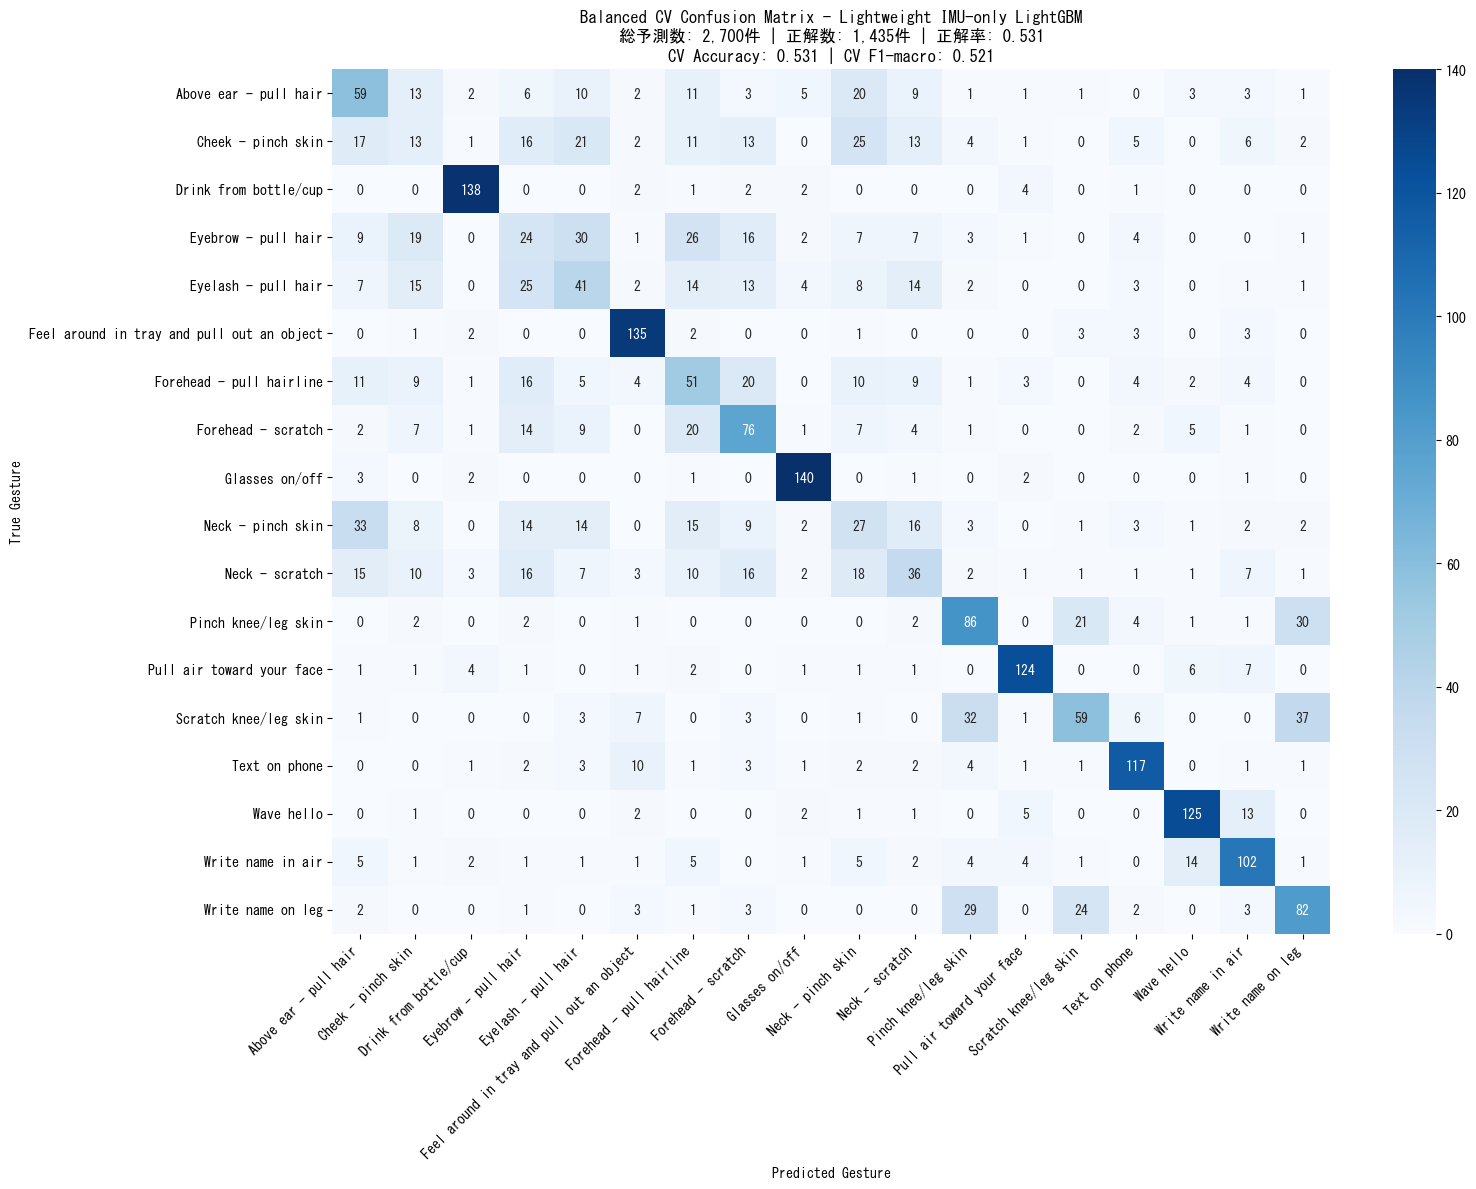


=== クラス別詳細統計 ===
Gesture                             真の件数     予測件数     正解件数     再現率      適合率     
-------------------------------------------------------------------------------------
Above ear - pull hair               150      165      59       0.393    0.358   
Cheek - pinch skin                  150      100      13       0.087    0.130   
Drink from bottle/cup               150      157      138      0.920    0.879   
Eyebrow - pull hair                 150      138      24       0.160    0.174   
Eyelash - pull hair                 150      144      41       0.273    0.285   
Feel around in tray and pull out an object 150      176      135      0.900    0.767   
Forehead - pull hairline            150      171      51       0.340    0.298   
Forehead - scratch                  150      177      76       0.507    0.429   
Glasses on/off                      150      163      140      0.933    0.859   
Neck - pinch skin                   150      133      27       0.180    0.203  

In [62]:
print("=== IMU-only モデル 学習・分析 ===")
(cm_imu_bal, y_true_imu_bal, y_pred_imu_bal, 
 trained_imu_model, imu_results) = balanced_cv_confusion_matrix_with_model(
    analysis_imu_model, X_imu_bal, y_imu_bal, groups_imu_bal, 
    "Lightweight IMU-only LightGBM", le_gesture.classes_, n_folds=CFG.n_folds
)

=== Full-sensor モデル 学習・分析 ===
=== Lightweight Full-sensor LightGBM バランスCV混同行列 (n_folds=5) ===
データサイズ: (2517, 872)
被験者グループ数: 79
Fold 1: Train=2016, Val=501
  Accuracy: 0.599, F1-macro: 0.585, Time: 28.7s
Fold 2: Train=2016, Val=501
  Accuracy: 0.563, F1-macro: 0.561, Time: 27.8s
Fold 3: Train=2015, Val=502
  Accuracy: 0.590, F1-macro: 0.577, Time: 28.9s
Fold 4: Train=2005, Val=512
  Accuracy: 0.545, F1-macro: 0.543, Time: 28.1s
Fold 5: Train=2016, Val=501
  Accuracy: 0.553, F1-macro: 0.548, Time: 29.3s

=== CV結果 ===
CV精度: 0.570
CV F1-macro: 0.562
CV実行時間: 142.8s


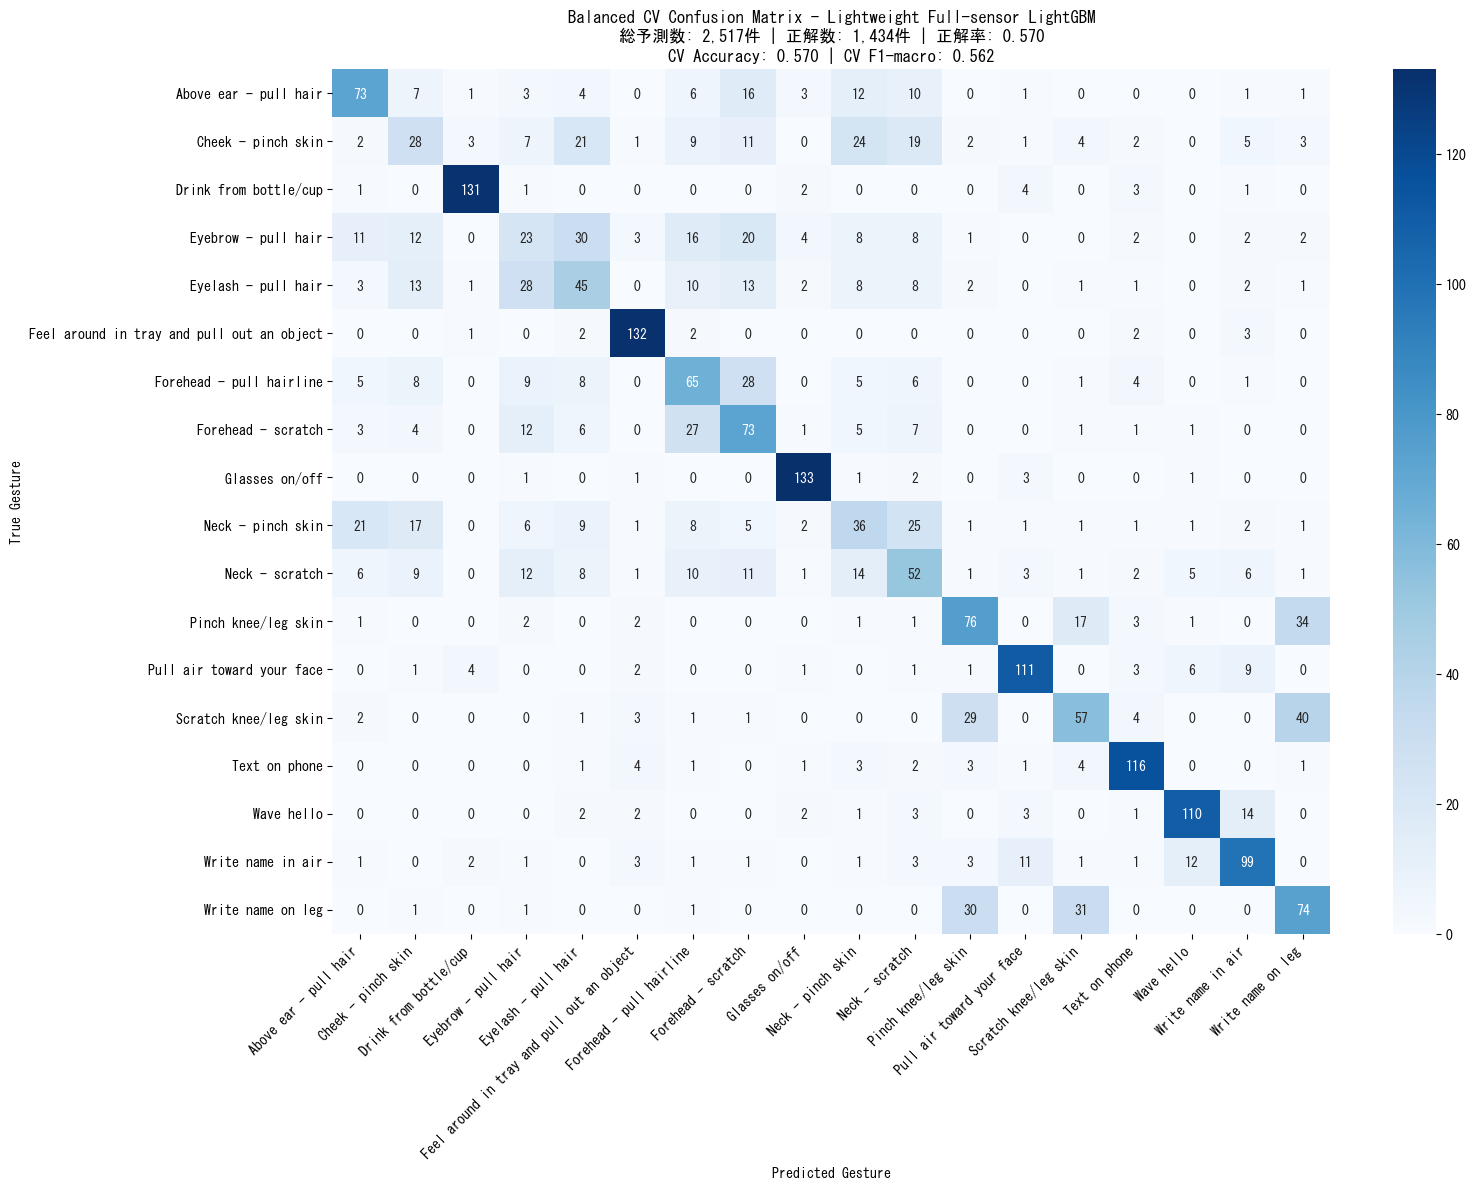


=== クラス別詳細統計 ===
Gesture                             真の件数     予測件数     正解件数     再現率      適合率     
-------------------------------------------------------------------------------------
Above ear - pull hair               138      129      73       0.529    0.566   
Cheek - pinch skin                  142      100      28       0.197    0.280   
Drink from bottle/cup               143      143      131      0.916    0.916   
Eyebrow - pull hair                 142      106      23       0.162    0.217   
Eyelash - pull hair                 138      137      45       0.326    0.328   
Feel around in tray and pull out an object 142      155      132      0.930    0.852   
Forehead - pull hairline            140      157      65       0.464    0.414   
Forehead - scratch                  141      179      73       0.518    0.408   
Glasses on/off                      142      152      133      0.937    0.875   
Neck - pinch skin                   138      119      36       0.261    0.303  

In [63]:
print("=== Full-sensor モデル 学習・分析 ===")
(cm_full_bal, y_true_full_bal, y_pred_full_bal, 
 trained_full_model, full_results) = balanced_cv_confusion_matrix_with_model(
    analysis_full_model, X_full_bal, y_full_bal, groups_full_bal, 
    "Lightweight Full-sensor LightGBM", le_gesture.classes_, n_folds=CFG.n_folds
)

# Feature importance

                              feature   importance
200                        rot_x_mean  3174.261429
292             angular_vel_z_fft_low  2070.552827
291       angular_vel_z_fft_max_no_dc  2032.208544
348  angular_vel_x_angular_vel_z_corr  1890.613659
63    linear_acc_jerk_x_fft_max_no_dc  1860.035013
290             angular_vel_z_fft_max  1717.621580
270            angular_vel_x_fft_high  1313.627573
269             angular_vel_x_fft_mid  1278.796659
293             angular_vel_z_fft_mid  1239.772253
344                  rot_x_rot_y_corr  1177.912901


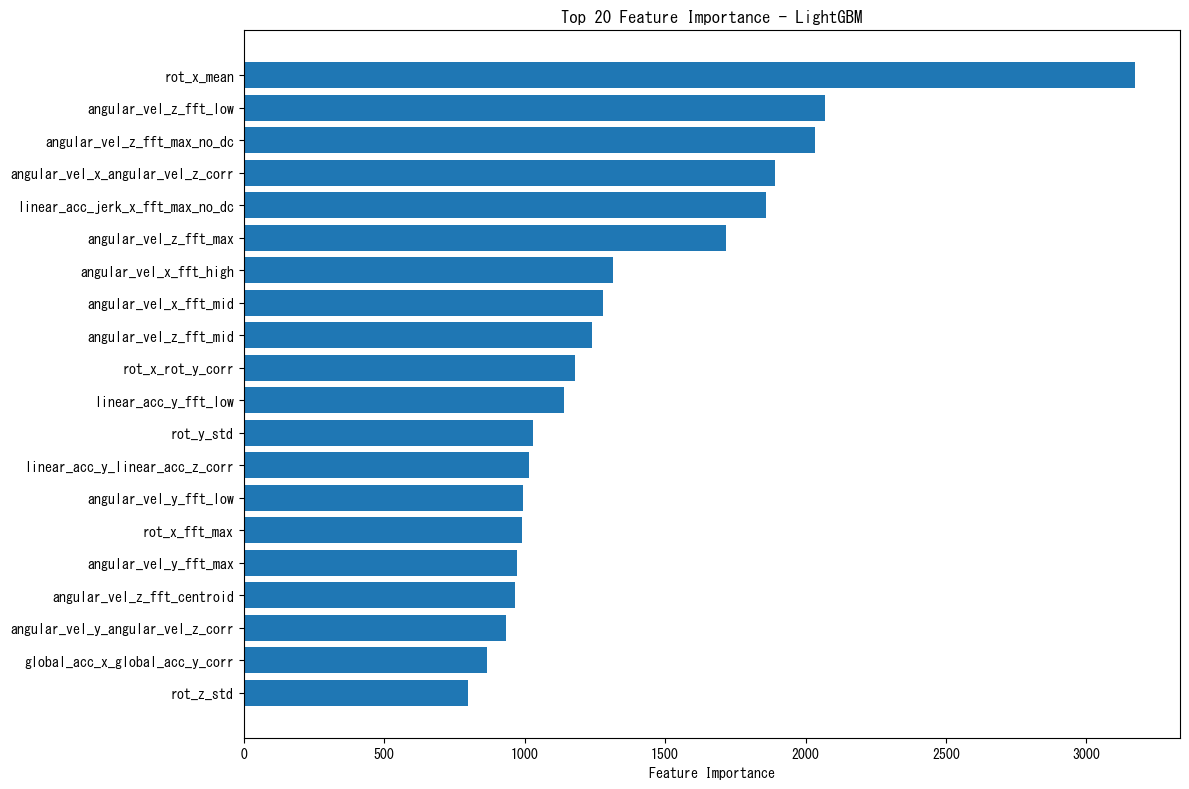

In [64]:
feature_importance = pd.DataFrame({
    'feature': X_imu_bal.columns,
    'importance': trained_imu_model.feature_importances_
}).sort_values('importance', ascending=False)

print(feature_importance.head(10))


# ===== 特徴量重要度の可視化 =====
if feature_importance is not None:
    plt.figure(figsize=(12, 8))
    
    # 上位20個の特徴量を表示
    top_features = feature_importance.head(20)
    
    plt.barh(range(len(top_features)), top_features['importance'])
    plt.yticks(range(len(top_features)), top_features['feature'])
    plt.xlabel('Feature Importance')
    plt.title(f'Top 20 Feature Importance - LightGBM')
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()
    
    # LSTM特徴量の分析
    lstm_features = feature_importance[feature_importance['feature'].str.contains('lstm_feat')]
    if not lstm_features.empty:
        print(f"\n=== LSTM特徴量重要度分析 ===")
        print(f"LSTM特徴量数: {len(lstm_features)}")
        print("上位20個のLSTM特徴量:")
        print(lstm_features.head(20))
        
        # センサー別の重要度
        sensor_importance = {}
        for _, row in lstm_features.iterrows():
            feature_name = row['feature']
            # tof_X_lstm_feat_Y からセンサー番号を抽出
            if 'tof_' in feature_name and 'lstm_feat_' in feature_name:
                sensor_id = feature_name.split('_')[1]  # tof_1 → 1
                if sensor_id not in sensor_importance:
                    sensor_importance[sensor_id] = []
                sensor_importance[sensor_id].append(row['importance'])
        
        if sensor_importance:
            print(f"\nセンサー別平均重要度:")
            for sensor_id in sorted(sensor_importance.keys()):
                avg_importance = np.mean(sensor_importance[sensor_id])
                print(f"  TOFセンサー{sensor_id}: {avg_importance:.4f}")


                              feature   importance
200                        rot_x_mean  3008.643733
360                        thm_2_mean  2838.823245
361                         thm_2_max  2207.084339
291       angular_vel_z_fft_max_no_dc  1992.983494
290             angular_vel_z_fft_max  1727.488742
292             angular_vel_z_fft_low  1699.216477
348  angular_vel_x_angular_vel_z_corr  1316.564282
362                        thm_3_mean  1232.249717
66         linear_acc_jerk_x_fft_high  1148.637161
269             angular_vel_x_fft_mid  1125.617621


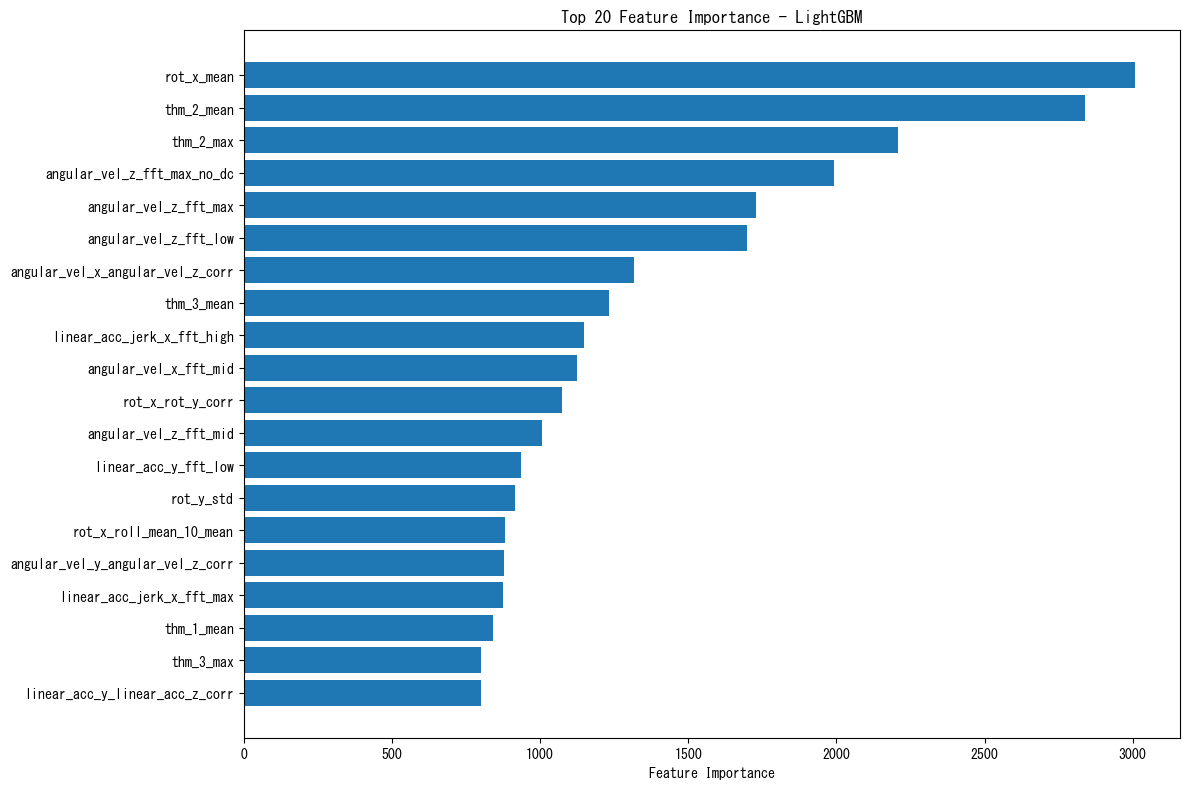


=== LSTM特徴量重要度分析 ===
LSTM特徴量数: 500
上位20個のLSTM特徴量:
                feature  importance
815  tof_5_lstm_feat_47  180.997230
585  tof_3_lstm_feat_17  175.717718
708  tof_4_lstm_feat_40  159.781121
588  tof_3_lstm_feat_20  149.488411
377   tof_1_lstm_feat_9  145.392296
596  tof_3_lstm_feat_28  139.262536
622  tof_3_lstm_feat_54  128.745422
444  tof_1_lstm_feat_76  123.278579
657  tof_3_lstm_feat_89  123.258216
850  tof_5_lstm_feat_82  114.474483
733  tof_4_lstm_feat_65  112.211177
575   tof_3_lstm_feat_7  111.542737
440  tof_1_lstm_feat_72  103.335090
655  tof_3_lstm_feat_87   97.984695
703  tof_4_lstm_feat_35   97.066825
714  tof_4_lstm_feat_46   93.631322
665  tof_3_lstm_feat_97   92.657919
743  tof_4_lstm_feat_75   90.502514
730  tof_4_lstm_feat_62   85.406557
673   tof_4_lstm_feat_5   82.844128

センサー別平均重要度:
  TOFセンサー1: 27.1834
  TOFセンサー2: 22.4681
  TOFセンサー3: 37.0070
  TOFセンサー4: 34.3202
  TOFセンサー5: 28.9377


In [65]:
feature_importance = pd.DataFrame({
    'feature': X_full_bal.columns,
    'importance': trained_full_model.feature_importances_
}).sort_values('importance', ascending=False)

print(feature_importance.head(10))


# ===== 特徴量重要度の可視化 =====
if feature_importance is not None:
    plt.figure(figsize=(12, 8))
    
    # 上位20個の特徴量を表示
    top_features = feature_importance.head(20)
    
    plt.barh(range(len(top_features)), top_features['importance'])
    plt.yticks(range(len(top_features)), top_features['feature'])
    plt.xlabel('Feature Importance')
    plt.title(f'Top 20 Feature Importance - LightGBM')
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()
    
    # LSTM特徴量の分析
    lstm_features = feature_importance[feature_importance['feature'].str.contains('lstm_feat')]
    if not lstm_features.empty:
        print(f"\n=== LSTM特徴量重要度分析 ===")
        print(f"LSTM特徴量数: {len(lstm_features)}")
        print("上位20個のLSTM特徴量:")
        print(lstm_features.head(20))
        
        # センサー別の重要度
        sensor_importance = {}
        for _, row in lstm_features.iterrows():
            feature_name = row['feature']
            # tof_X_lstm_feat_Y からセンサー番号を抽出
            if 'tof_' in feature_name and 'lstm_feat_' in feature_name:
                sensor_id = feature_name.split('_')[1]  # tof_1 → 1
                if sensor_id not in sensor_importance:
                    sensor_importance[sensor_id] = []
                sensor_importance[sensor_id].append(row['importance'])
        
        if sensor_importance:
            print(f"\nセンサー別平均重要度:")
            for sensor_id in sorted(sensor_importance.keys()):
                avg_importance = np.mean(sensor_importance[sensor_id])
                print(f"  TOFセンサー{sensor_id}: {avg_importance:.4f}")


In [77]:
def analyze_gesture_prediction_by_orientation(train_data, y_true, y_pred, X_index, le_gesture, target_gesture):
    """
    orientation別に指定したジェスチャーの予測精度を分析・可視化
    
    Parameters:
    -----------
    train_data : pd.DataFrame
        学習データ
    y_true : list
        真のラベル
    y_pred : list  
        予測ラベル
    X_index : pd.Index
        特徴量のインデックス（sequence_id）
    le_gesture : LabelEncoder
        ジェスチャーのラベルエンコーダー
    target_gesture : str
        分析対象のジェスチャー名（例：'Cheek - pinch skin'）
    
    Returns:
    --------
    tuple : (orientation_stats, gesture_df)
        orientation別統計とジェスチャー詳細データ
    """
    print(f"=== {target_gesture} の orientation別予測精度分析 ===")
    
    # 1. orientationの値確認
    print("trainデータのorientation値:")
    print(train_data['orientation'].value_counts())
    
    # 2. 指定ジェスチャーのクラスID取得
    try:
        target_class_id = le_gesture.transform([target_gesture])[0]
        print(f"\n{target_gesture} のクラスID: {target_class_id}")
    except ValueError:
        print(f"エラー: '{target_gesture}' がラベルエンコーダーに見つかりません")
        print(f"利用可能なジェスチャー: {list(le_gesture.classes_)}")
        return None, None
    
    # 3. 予測結果とtrainデータをマッチング
    # sequence_idをキーにしてorientationを取得
    sequence_to_orientation = train_data.groupby('sequence_id')['orientation'].first()
    
    # X_indexに対応するorientationを取得
    orientations_for_predictions = []
    valid_indices = []
    
    for i, seq_id in enumerate(X_index):
        if seq_id in sequence_to_orientation.index:
            orientations_for_predictions.append(sequence_to_orientation[seq_id])
            valid_indices.append(i)
        else:
            print(f"Warning: sequence_id {seq_id} not found in train data")
    
    # 有効なインデックスのみでフィルタ
    y_true_filtered = [y_true[i] for i in valid_indices]
    y_pred_filtered = [y_pred[i] for i in valid_indices]
    orientations_filtered = orientations_for_predictions
    
    print(f"\n予測結果とマッチしたシーケンス数: {len(valid_indices)}")
    
    # 4. 指定ジェスチャーのみを抽出
    gesture_results = []
    
    for i in range(len(y_true_filtered)):
        if y_true_filtered[i] == target_class_id:  # 真のクラスが指定ジェスチャー
            gesture_results.append({
                'orientation': orientations_filtered[i],
                'true_label': y_true_filtered[i],
                'pred_label': y_pred_filtered[i],
                'is_correct': y_true_filtered[i] == y_pred_filtered[i]
            })
    
    if not gesture_results:
        print(f"{target_gesture} のデータが見つかりませんでした")
        return None, None
    
    gesture_df = pd.DataFrame(gesture_results)
    print(f"\n{target_gesture} の総予測数: {len(gesture_df)}")
    
    # 5. orientation別の集計
    orientation_stats = gesture_df.groupby('orientation').agg({
        'is_correct': ['count', 'sum']
    }).round(3)
    
    orientation_stats.columns = ['total_count', 'correct_count']
    orientation_stats['incorrect_count'] = orientation_stats['total_count'] - orientation_stats['correct_count']
    orientation_stats['accuracy'] = orientation_stats['correct_count'] / orientation_stats['total_count']
    
    print(f"\n=== Orientation別統計 ===")
    print(orientation_stats)
    
    # 6. 可視化
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
    
    # 6-1. 件数の棒グラフ
    orientations = orientation_stats.index
    correct_counts = orientation_stats['correct_count']
    incorrect_counts = orientation_stats['incorrect_count']
    
    x_pos = np.arange(len(orientations))
    width = 0.35
    
    bars1 = ax1.bar(x_pos, correct_counts, width, label='正解', color='green', alpha=0.7)
    bars2 = ax1.bar(x_pos, incorrect_counts, width, bottom=correct_counts, 
                    label='不正解', color='red', alpha=0.7)
    
    ax1.set_xlabel('Orientation')
    ax1.set_ylabel('件数')
    ax1.set_title(f'{target_gesture} の Orientation別 正解・不正解件数')
    ax1.set_xticks(x_pos)
    ax1.set_xticklabels(orientations, rotation=45, ha='right')
    ax1.legend()
    ax1.grid(axis='y', alpha=0.3)
    
    # 棒グラフに数値を表示
    for i, (correct, incorrect) in enumerate(zip(correct_counts, incorrect_counts)):
        total = correct + incorrect
        # 正解件数
        if correct > 0:
            ax1.text(i, correct/2, str(int(correct)), ha='center', va='center', fontweight='bold')
        # 不正解件数
        if incorrect > 0:
            ax1.text(i, correct + incorrect/2, str(int(incorrect)), ha='center', va='center', fontweight='bold')
        # 全体件数を棒の上に表示
        ax1.text(i, total + 0.5, f'total:{int(total)}', ha='center', va='bottom', fontsize=10)
    
    # 6-2. 正解率の棒グラフ
    accuracy_bars = ax2.bar(x_pos, orientation_stats['accuracy'], color='skyblue', alpha=0.7)
    
    ax2.set_xlabel('Orientation')
    ax2.set_ylabel('正解率')
    ax2.set_title(f'{target_gesture} の Orientation別 正解率')
    ax2.set_xticks(x_pos)
    ax2.set_xticklabels(orientations, rotation=45, ha='right')
    ax2.set_ylim(0, 1.0)
    ax2.grid(axis='y', alpha=0.3)
    
    # 正解率を棒の上に表示
    for i, acc in enumerate(orientation_stats['accuracy']):
        ax2.text(i, acc + 0.02, f'{acc:.3f}', ha='center', va='bottom', fontweight='bold')
    
    plt.tight_layout()
    plt.show()
    
    # 7. 詳細分析：不正解の場合、何に誤分類されたか
    if len(gesture_df[~gesture_df['is_correct']]) > 0:
        print(f"\n=== 不正解時の誤分類先分析 ===")
        incorrect_df = gesture_df[~gesture_df['is_correct']]
        
        # 誤分類先のジェスチャー名を取得
        incorrect_df['pred_gesture'] = le_gesture.inverse_transform(incorrect_df['pred_label'])
        
        # orientation別の誤分類先集計
        misclassification_summary = incorrect_df.groupby(['orientation', 'pred_gesture']).size().reset_index(name='count')
        
        for orientation in orientations:
            orientation_misc = misclassification_summary[misclassification_summary['orientation'] == orientation]
            if len(orientation_misc) > 0:
                print(f"\n{orientation}:")
                for _, row in orientation_misc.iterrows():
                    print(f"  → {row['pred_gesture']}: {row['count']}件")
    
    return orientation_stats, gesture_df

=== Cheek - pinch skin の分析 ===
=== Cheek - pinch skin の orientation別予測精度分析 ===
trainデータのorientation値:
orientation
Seated Straight                    77174
Seated Lean Non Dom - FACE DOWN    56185
Lie on Back                        32064
Lie on Side - Non Dominant         30865
Name: count, dtype: int64

Cheek - pinch skin のクラスID: 1

予測結果とマッチしたシーケンス数: 2700

Cheek - pinch skin の総予測数: 150

=== Orientation別統計 ===
                                 total_count  correct_count  incorrect_count  \
orientation                                                                    
Lie on Back                               17              1               16   
Lie on Side - Non Dominant                28              2               26   
Seated Lean Non Dom - FACE DOWN           47              2               45   
Seated Straight                           58              8               50   

                                 accuracy  
orientation                                
Lie on Back       

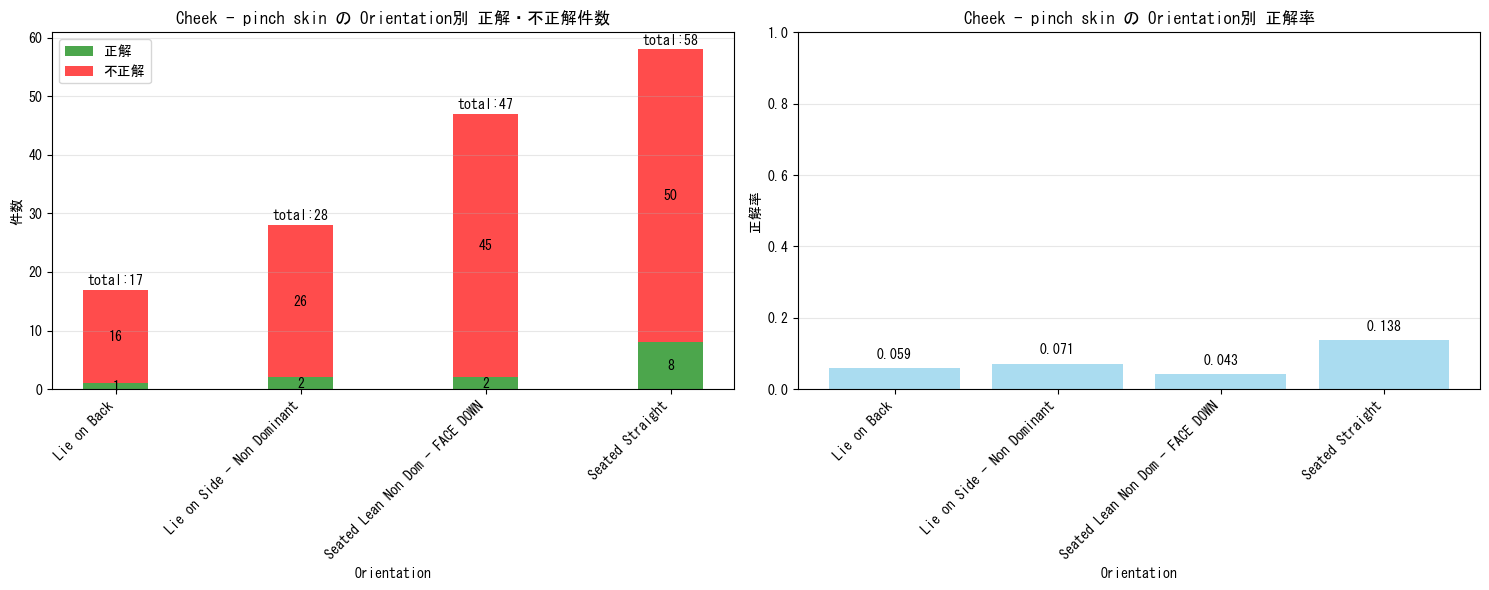


=== 不正解時の誤分類先分析 ===

Lie on Back:
  → Above ear - pull hair: 3件
  → Eyebrow - pull hair: 1件
  → Eyelash - pull hair: 2件
  → Forehead - pull hairline: 2件
  → Neck - pinch skin: 3件
  → Neck - scratch: 2件
  → Text on phone: 1件
  → Write name in air: 2件

Lie on Side - Non Dominant:
  → Above ear - pull hair: 5件
  → Eyebrow - pull hair: 4件
  → Eyelash - pull hair: 3件
  → Forehead - pull hairline: 1件
  → Forehead - scratch: 1件
  → Neck - pinch skin: 3件
  → Neck - scratch: 3件
  → Pinch knee/leg skin: 2件
  → Text on phone: 2件
  → Write name in air: 2件

Seated Lean Non Dom - FACE DOWN:
  → Above ear - pull hair: 3件
  → Drink from bottle/cup: 1件
  → Eyebrow - pull hair: 5件
  → Eyelash - pull hair: 4件
  → Feel around in tray and pull out an object: 1件
  → Forehead - pull hairline: 5件
  → Forehead - scratch: 4件
  → Neck - pinch skin: 11件
  → Neck - scratch: 7件
  → Pinch knee/leg skin: 1件
  → Pull air toward your face: 1件
  → Write name in air: 1件
  → Write name on leg: 1件

Seated Straight:
  → Ab

In [78]:
print("=== Cheek - pinch skin の分析 ===")
cheek_analysis = analyze_gesture_prediction_by_orientation(
    train_balanced, y_true_imu_bal, y_pred_imu_bal, X_imu_bal.index, le_gesture, 
    target_gesture='Cheek - pinch skin'
)

=== Eyelash - pull hair の分析 ===
=== Eyelash - pull hair の orientation別予測精度分析 ===
trainデータのorientation値:
orientation
Seated Straight                    77174
Seated Lean Non Dom - FACE DOWN    56185
Lie on Back                        32064
Lie on Side - Non Dominant         30865
Name: count, dtype: int64

Eyelash - pull hair のクラスID: 4

予測結果とマッチしたシーケンス数: 2700

Eyelash - pull hair の総予測数: 150

=== Orientation別統計 ===
                                 total_count  correct_count  incorrect_count  \
orientation                                                                    
Lie on Back                               38             11               27   
Lie on Side - Non Dominant                29              9               20   
Seated Lean Non Dom - FACE DOWN           38              9               29   
Seated Straight                           45             12               33   

                                 accuracy  
orientation                                
Lie on Back   

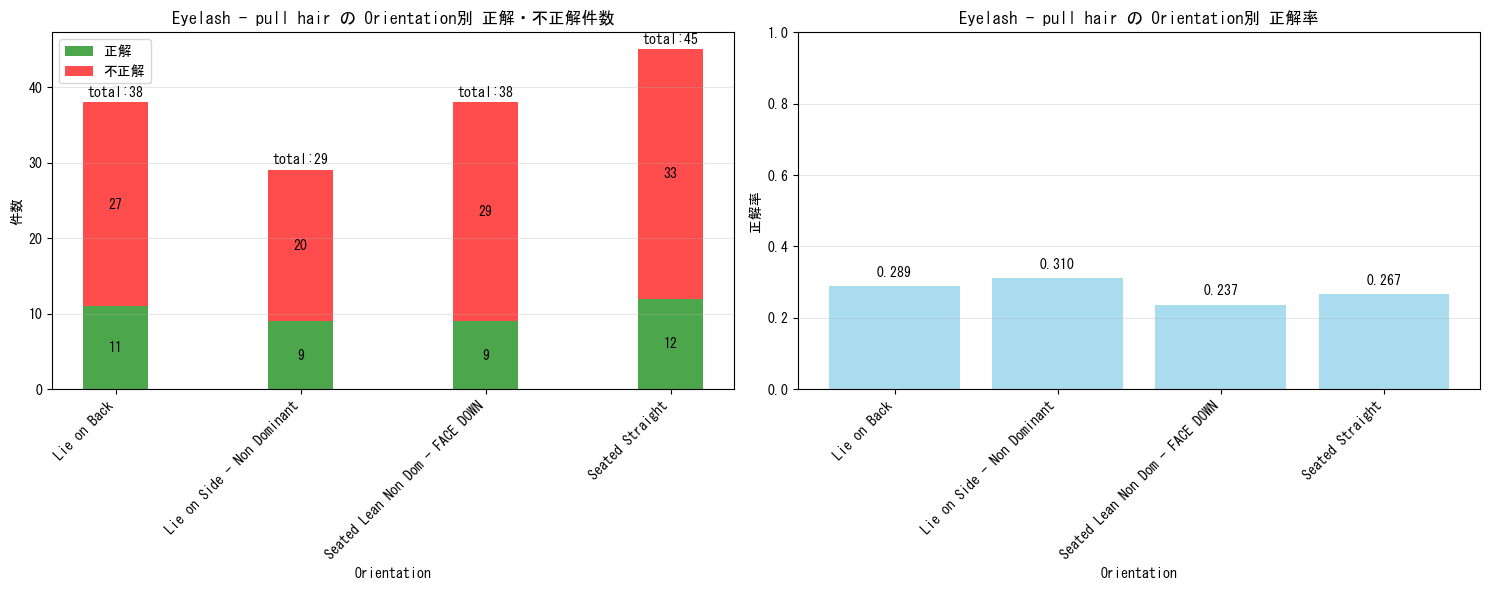


=== 不正解時の誤分類先分析 ===

Lie on Back:
  → Above ear - pull hair: 3件
  → Cheek - pinch skin: 2件
  → Eyebrow - pull hair: 8件
  → Feel around in tray and pull out an object: 1件
  → Forehead - pull hairline: 2件
  → Forehead - scratch: 4件
  → Glasses on/off: 2件
  → Neck - pinch skin: 3件
  → Neck - scratch: 1件
  → Text on phone: 1件

Lie on Side - Non Dominant:
  → Above ear - pull hair: 1件
  → Cheek - pinch skin: 1件
  → Eyebrow - pull hair: 5件
  → Forehead - pull hairline: 5件
  → Forehead - scratch: 4件
  → Glasses on/off: 1件
  → Neck - scratch: 2件
  → Write name in air: 1件

Seated Lean Non Dom - FACE DOWN:
  → Above ear - pull hair: 2件
  → Cheek - pinch skin: 6件
  → Eyebrow - pull hair: 5件
  → Feel around in tray and pull out an object: 1件
  → Forehead - pull hairline: 4件
  → Glasses on/off: 1件
  → Neck - pinch skin: 4件
  → Neck - scratch: 3件
  → Pinch knee/leg skin: 1件
  → Text on phone: 2件

Seated Straight:
  → Above ear - pull hair: 1件
  → Cheek - pinch skin: 6件
  → Eyebrow - pull hair: 7件
 

In [79]:
print("=== Eyelash - pull hair の分析 ===")
eyelash_analysis = analyze_gesture_prediction_by_orientation(
    train_balanced, y_true_imu_bal, y_pred_imu_bal, X_imu_bal.index, le_gesture, 
    target_gesture='Eyelash - pull hair'
)

=== Text on phone の分析 ===
=== Text on phone の orientation別予測精度分析 ===
trainデータのorientation値:
orientation
Seated Straight                    77174
Seated Lean Non Dom - FACE DOWN    56185
Lie on Back                        32064
Lie on Side - Non Dominant         30865
Name: count, dtype: int64

Text on phone のクラスID: 14

予測結果とマッチしたシーケンス数: 2700

Text on phone の総予測数: 150

=== Orientation別統計 ===
                                 total_count  correct_count  incorrect_count  \
orientation                                                                    
Lie on Back                               29             25                4   
Lie on Side - Non Dominant                21             17                4   
Seated Lean Non Dom - FACE DOWN           46             34               12   
Seated Straight                           54             41               13   

                                 accuracy  
orientation                                
Lie on Back                      0.86

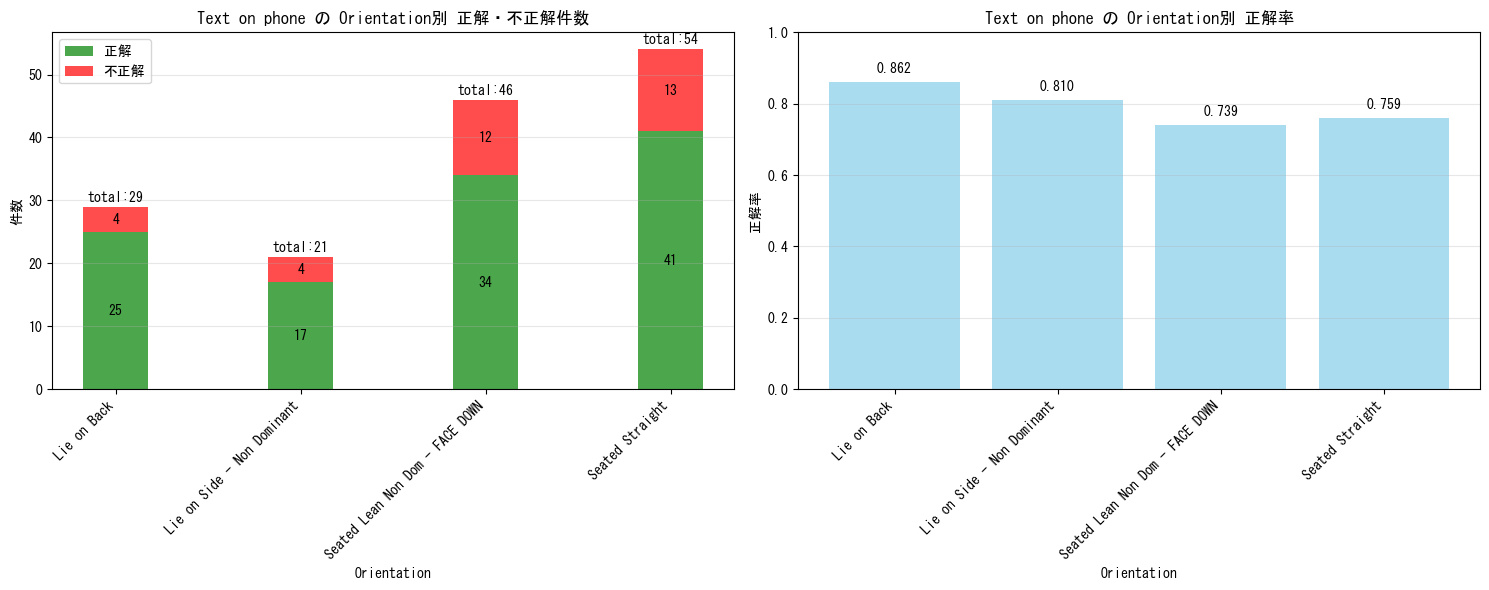


=== 不正解時の誤分類先分析 ===

Lie on Back:
  → Eyebrow - pull hair: 1件
  → Feel around in tray and pull out an object: 2件
  → Scratch knee/leg skin: 1件

Lie on Side - Non Dominant:
  → Drink from bottle/cup: 1件
  → Feel around in tray and pull out an object: 3件

Seated Lean Non Dom - FACE DOWN:
  → Eyelash - pull hair: 1件
  → Feel around in tray and pull out an object: 3件
  → Forehead - pull hairline: 1件
  → Forehead - scratch: 2件
  → Neck - pinch skin: 2件
  → Pinch knee/leg skin: 2件
  → Pull air toward your face: 1件

Seated Straight:
  → Eyebrow - pull hair: 1件
  → Eyelash - pull hair: 2件
  → Feel around in tray and pull out an object: 2件
  → Forehead - scratch: 1件
  → Glasses on/off: 1件
  → Neck - scratch: 2件
  → Pinch knee/leg skin: 2件
  → Write name in air: 1件
  → Write name on leg: 1件


In [80]:
print("=== Text on phone の分析 ===")
text_analysis = analyze_gesture_prediction_by_orientation(
    train_balanced, y_true_imu_bal, y_pred_imu_bal, X_imu_bal.index, le_gesture, 
    target_gesture='Text on phone'
)